This notebook trains and evaluates pet-face emotion classifiers using:
- A custom MobileNet (V1-style) trained from scratch
- Transfer learning with an ImageNet-pretrained MobileNetV2
Metrics reported: accuracy, macro-precision/recall/F1, and confusion matrix.

## Imports & Setup
Load libraries, dataloaders, and helper plotting/metrics functions.

In [1]:
import os
import importlib
import torch
import torch.nn as nn
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
import timm
from data_loader import get_dataloaders, DataLoaderConfig

import utils
importlib.reload(utils)
from utils import plot_loss_and_accuracy, report_classification_metrics

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model (From Scratch)
MobileNetV1-style network using depthwise separable convolutions.

In [7]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.depthwise = nn.Sequential(
            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=in_channels,
                bias=False
            ),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )

        self.pointwise = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


class MobileNetV1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            DepthwiseSeparableConv(32, 64, stride=1),
            DepthwiseSeparableConv(64, 128, stride=2),
            DepthwiseSeparableConv(128, 128, stride=1),
            DepthwiseSeparableConv(128, 256, stride=2),
            DepthwiseSeparableConv(256, 256, stride=1),
            DepthwiseSeparableConv(256, 512, stride=2),

            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),

            DepthwiseSeparableConv(512, 1024, stride=2),
            DepthwiseSeparableConv(1024, 1024, stride=1),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Linear(1024, num_classes)

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

## Training & Validation Loops
Define per-epoch training and evaluation functions (loss + accuracy).

In [8]:
def train_one_epoch(model, train_loader, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        criterion = nn.CrossEntropyLoss()
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [9]:
@torch.no_grad()
def evaluate_one_epoch(model, test_loader, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(test_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            criterion = nn.CrossEntropyLoss()
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [10]:
loader, classes = get_dataloaders(DataLoaderConfig())
train_loader = loader['train']
val_loader = loader['valid']
test_loader = loader['test']

## Train From Scratch
Train MobileNetV1 from scratch, cache the best checkpoint by validation loss, then plot learning curves.

In [11]:
# train the model (cache best checkpoint by validation loss)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MobileNetV1(num_classes=len(classes)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), 
    lr=1e-3, 
    weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5)

best_ckpt_path = os.path.join("models", "best_mobilenet_v1.pth")
os.makedirs("models", exist_ok=True)
best_val_loss = float("inf")

num_epochs = 50
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_acc = evaluate_one_epoch(model, val_loader, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # cache best model
    if val_loss < best_val_loss:
        print(f"\tNew best model found at epoch {epoch+1} with val_loss={val_loss:.4f}, val_acc={val_acc:.2f}")
        best_val_loss = val_loss
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_acc": val_acc,
                "classes": classes,
            },
            best_ckpt_path,
        )

    scheduler.step(val_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Learning Rate: {optimizer.param_groups[0]["lr"]:.6f}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

print(f"Best checkpoint saved to: {best_ckpt_path} (val_loss={best_val_loss:.4f})")

	New best model found at epoch 1 with val_loss=1.6653, val_acc=16.67
Epoch 1/50, Learning Rate: 0.001000, Train Loss: 1.4253, Train Acc: 27.30%, Val Loss: 1.6653, Val Acc: 16.67%
Epoch 2/50, Learning Rate: 0.001000, Train Loss: 1.3974, Train Acc: 29.40%, Val Loss: 1.8530, Val Acc: 25.00%
	New best model found at epoch 3 with val_loss=1.0732, val_acc=36.11
Epoch 3/50, Learning Rate: 0.001000, Train Loss: 1.4129, Train Acc: 29.60%, Val Loss: 1.0732, Val Acc: 36.11%
Epoch 4/50, Learning Rate: 0.001000, Train Loss: 1.3604, Train Acc: 32.20%, Val Loss: 1.6516, Val Acc: 30.56%
Epoch 5/50, Learning Rate: 0.001000, Train Loss: 1.3439, Train Acc: 35.50%, Val Loss: 1.1858, Val Acc: 30.56%
Epoch 6/50, Learning Rate: 0.001000, Train Loss: 1.3417, Train Acc: 37.40%, Val Loss: 2.2634, Val Acc: 25.00%
Epoch 7/50, Learning Rate: 0.000500, Train Loss: 1.3398, Train Acc: 36.80%, Val Loss: 1.3273, Val Acc: 30.56%
	New best model found at epoch 8 with val_loss=1.0730, val_acc=41.67
Epoch 8/50, Learning Ra

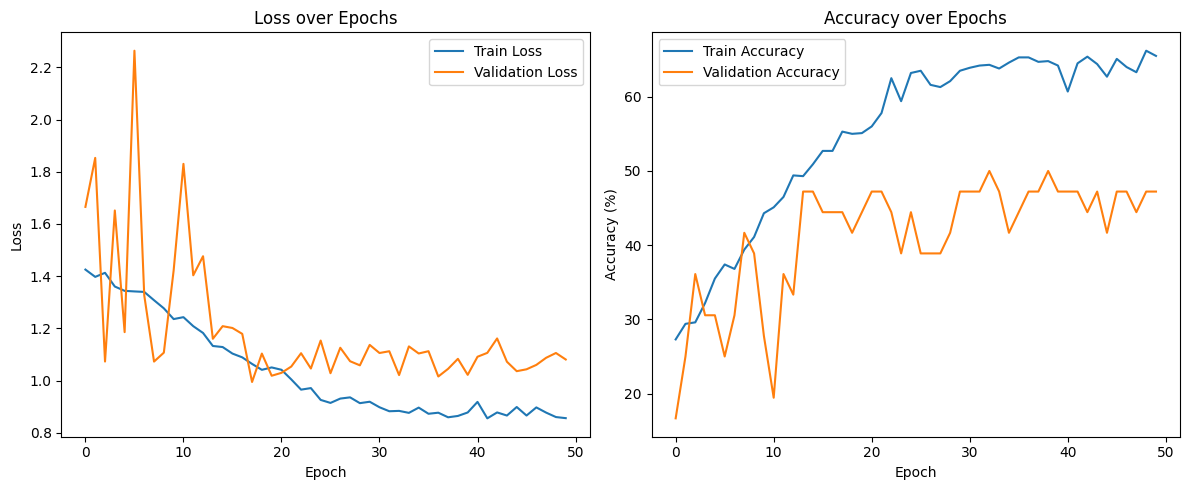

In [12]:
plot_loss_and_accuracy(train_losses, val_losses, train_accuracies, val_accuracies)

## Test Set Evaluation & Report
Load the best cached checkpoint (if available), evaluate on the test set, and report accuracy, macro Precision/Recall/F1, and the confusion matrix.

Loaded best checkpoint: models\best_mobilenet_v1.pth (val_loss=0.9948820173740387)
Test Loss: 1.6171, Test Acc: 28.95%
MobileNetV1 - Accuracy: 28.95%
MobileNetV1 - Macro Precision/Recall/F1: 0.2870 / 0.2758 / 0.2794
MobileNetV1 - Confusion Matrix (rows=true, cols=pred):
[[3 2 2 3]
 [3 1 1 1]
 [1 0 4 6]
 [4 2 2 3]]


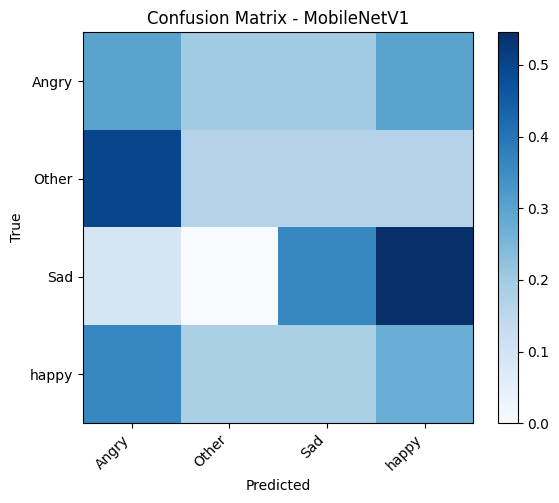

In [13]:
# inference on test set (load best cached checkpoint if available)
if 'best_ckpt_path' in globals() and os.path.exists(best_ckpt_path):
    ckpt = torch.load(best_ckpt_path, map_location=device)
    state = ckpt.get("model_state_dict", ckpt)
    model.load_state_dict(state)
    print(f"Loaded best checkpoint: {best_ckpt_path} (val_loss={ckpt.get('val_loss', 'n/a')})")
else:
    print("No cached checkpoint found; evaluating current model weights.")

test_loss, test_acc = evaluate_one_epoch(model, test_loader, device)
print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
metrics = report_classification_metrics(
    model,
    test_loader,
    device,
    class_names=classes,
    title="MobileNetV1",
    plot_confusion_matrix=True,
    normalize_confusion_matrix="true",  # optional: None/'true'/'pred'/'all'
)

## Transfer Learning (ImageNet Weights)
Fine-tune an ImageNet-pretrained MobileNetV2 on the same dataset, cache the best checkpoint, then evaluate on the test set with the same metrics.

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--timm--mobilenetv1_100.ra4_e3600_r224_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


	New best TL model @ epoch 1: val_loss=4.5376, val_acc=25.00%
[TL] Epoch 1/10 lr=1.00e-03 train_loss=4.3941 train_acc=22.60% val_loss=4.5376 val_acc=25.00%
[TL] Epoch 2/10 lr=1.00e-03 train_loss=3.7885 train_acc=23.80% val_loss=4.7503 val_acc=30.56%
	New best TL model @ epoch 3: val_loss=4.1960, val_acc=27.78%
[TL] Epoch 3/10 lr=1.00e-03 train_loss=3.6874 train_acc=27.70% val_loss=4.1960 val_acc=27.78%
	New best TL model @ epoch 4: val_loss=3.7959, val_acc=33.33%
[TL] Epoch 4/10 lr=1.00e-03 train_loss=3.4717 train_acc=27.30% val_loss=3.7959 val_acc=33.33%
	New best TL model @ epoch 5: val_loss=3.5226, val_acc=33.33%
[TL] Epoch 5/10 lr=1.00e-03 train_loss=3.4840 train_acc=27.80% val_loss=3.5226 val_acc=33.33%
[TL] Epoch 6/10 lr=1.00e-03 train_loss=3.2754 train_acc=27.90% val_loss=3.6472 val_acc=33.33%
[TL] Epoch 7/10 lr=1.00e-03 train_loss=2.9027 train_acc=34.70% val_loss=3.8614 val_acc=30.56%
[TL] Epoch 8/10 lr=5.00e-04 train_loss=2.9552 train_acc=32.10% val_loss=3.6103 val_acc=27.78%


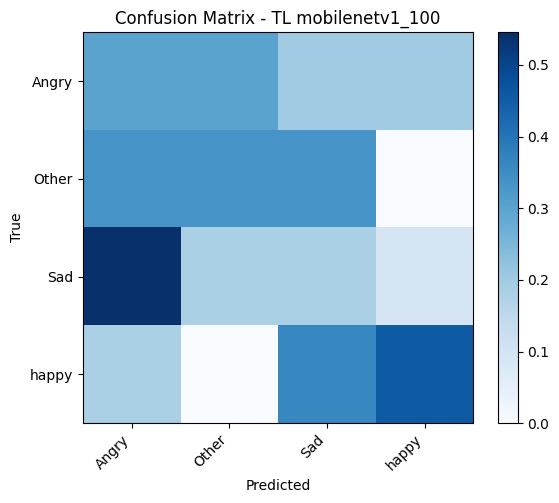

In [14]:
tl_model_name = "mobilenetv1_100"
tl_epochs = 10

tl_best_ckpt = os.path.join("models", f"best_tl_{tl_model_name}.pth")
os.makedirs("models", exist_ok=True)

# build pretrained model + replace classifier
tl_model = timm.create_model(
    "mobilenetv1_100",
    pretrained=True,
    num_classes=len(classes)
)


# freeze all layers
for p in tl_model.parameters():
    p.requires_grad = False

# unfreeze classifier/head
for p in tl_model.classifier.parameters():
    p.requires_grad = True

tl_model = tl_model.to(device)

tl_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, tl_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)
tl_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    tl_optimizer, mode="min", patience=2, factor=0.5
)

best_val = float("inf")
for epoch in range(tl_epochs):
    tr_loss, tr_acc = train_one_epoch(tl_model, train_loader, tl_optimizer, device)
    va_loss, va_acc = evaluate_one_epoch(tl_model, val_loader, device)
    tl_scheduler.step(va_loss)

    if va_loss < best_val:
        best_val = va_loss
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": tl_model.state_dict(),
                "val_loss": va_loss,
                "val_acc": va_acc,
                "classes": classes,
            },
            tl_best_ckpt,
        )
        print(f"\tNew best TL model @ epoch {epoch+1}: val_loss={va_loss:.4f}, val_acc={va_acc:.2f}%")

    print(
        f"[TL] Epoch {epoch+1}/{tl_epochs} "
        f"lr={tl_optimizer.param_groups[0]['lr']:.2e} "
        f"train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% "
        f"val_loss={va_loss:.4f} val_acc={va_acc:.2f}%"
    )

print(f"Best TL checkpoint: {tl_best_ckpt} (val_loss={best_val:.4f})")

# ---- load best + evaluate on test ----
ckpt = torch.load(tl_best_ckpt, map_location=device)
tl_model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded TL checkpoint: {tl_best_ckpt} (val_loss={ckpt.get('val_loss')}, val_acc={ckpt.get('val_acc')})")

metrics_tl = report_classification_metrics(
    tl_model,
    test_loader,
    device,
    class_names=classes,
    title=f"TL {tl_model_name}",
    plot_confusion_matrix=True,
    normalize_confusion_matrix="true",
)